# MTG Reprint Effect Analysis

**Research questions:**
1. How much does a card's price drop after a reprint, by set type?
2. How quickly does it rebound, and does it ever fully recover?
3. Does the original printing hold value better than the new reprint version?
4. Do high-value cards start declining *before* the official announcement? (leakage)

**Event study design:**
- T = 0: reprint set release date
- T = −90: drift detection start (pre-announcement leakage window)
- T = −45: clean baseline (pre-dates most set announcements)
- T = −21: preview season opens
- T = +7: end of release-week shock
- Baseline price = median NM sell price in [T−52, T−38]
- Normalized price: indexed_price = daily_price / baseline_price

In [ ]:
import os
import warnings
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

REFRESH = False # Set False to load from parquet cache

EVENT_WINDOW    = (-90, 365)   # days relative to reprint release
BASELINE_WINDOW = (-52, -38)   # days for baseline price computation
DRIFT_WINDOW    = (-90, -45)   # pre-announcement leakage window
RARITY_FILTER   = ['mythic', 'rare']
RARITY_ORDER    = ['mythic', 'rare']
RARITY_COLORS   = {'mythic': '#e07b39', 'rare': '#c5a800'}
MIN_BUCKET_SIZE = 5             # min events to include a set type in charts
LEAKAGE_PRICE_THRESHOLD = 1500  # cents — only analyze leakage for cards > $15 at T-90

SET_TYPE_DEFAULT = {
    'masters':          'masters',
    'expansion':        'expansion',
    'core':             'core',
    'commander':        'commander',
    'draft_innovation': 'list_jumpstart',
    'masterpiece':      'list_jumpstart',
}

SET_CODE_OVERRIDES = {
    'mh2': 'masters',  'mh3': 'masters',  'h1r': 'masters',  'h2r': 'masters',
    'ltr': 'ub_large', 'clb': 'ub_large', 'acr': 'ub_large',
    'fin': 'ub_large', 'eoe': 'ub_large', 'spm': 'ub_large',
    'tla': 'ub_large', 'tmt': 'ub_large', 'sos': 'ub_large', 'ecl': 'ub_large',
    'who': 'ub_large', 'pip': 'ub_large', '40k': 'ub_large',
    'slx': 'secret_lair',
}

SET_TYPE_ORDER  = ['masters', 'expansion', 'core', 'commander', 'ub_large', 'list_jumpstart', 'secret_lair']
SET_TYPE_COLORS = {
    'masters':        '#7f00ff',
    'expansion':      '#e07b39',
    'core':           '#c5a800',
    'commander':      '#2e7d32',
    'ub_large':       '#0288d1',
    'list_jumpstart': '#546e7a',
    'secret_lair':    '#c62828',
}

def classify_set_type(set_code: str, raw_set_type: str) -> str:
    if set_code in SET_CODE_OVERRIDES:
        return SET_CODE_OVERRIDES[set_code]
    return SET_TYPE_DEFAULT.get(raw_set_type, 'other')

DB_CONFIG = dict(
    host='localhost', port=5433, dbname='automana', user='automana_admin',
    password=os.environ.get('AUTOMANA_DB_PASSWORD', ''),
)

def get_conn():
    return psycopg2.connect(**DB_CONFIG)

def query_to_df(sql, params=None):
    with get_conn() as conn:
        cur = conn.cursor()
        cur.execute(sql, params)
        cols = [d[0] for d in cur.description]
        rows = cur.fetchall()
    return pd.DataFrame(rows, columns=cols)

print('Setup complete.')

Setup complete.


## Part 1 — Reprint Event Catalog

For every mythic/rare, find all printings ordered by `released_at`.  
The earliest printing is the "original". Every subsequent printing is a **reprint event**.  
We classify each event by `reprint_set_type` using our 7-bucket taxonomy.

In [3]:
SQL_EVENTS = """
WITH card_first_print AS (
    SELECT
        cv.unique_card_id,
        MIN(s.released_at) AS first_release
    FROM card_catalog.card_version cv
    JOIN card_catalog.sets s ON s.set_id = cv.set_id
    JOIN card_catalog.rarities_ref r ON r.rarity_id = cv.rarity_id
    WHERE r.rarity_name IN ('mythic', 'rare')
      AND NOT cv.is_digital
    GROUP BY cv.unique_card_id
),
original_set AS (
    SELECT DISTINCT ON (cv.unique_card_id)
        cv.unique_card_id,
        s.set_code AS original_set
    FROM card_catalog.card_version cv
    JOIN card_catalog.sets s ON s.set_id = cv.set_id
    JOIN card_first_print cfp ON cfp.unique_card_id = cv.unique_card_id
    WHERE s.released_at = cfp.first_release
    ORDER BY cv.unique_card_id, s.set_code
)
SELECT DISTINCT
    cv.unique_card_id::text,
    ucr.card_name,
    r.rarity_name,
    os.original_set,
    cfp.first_release           AS original_release,
    s.set_code                  AS reprint_set,
    s.set_name                  AS reprint_set_name,
    st.set_type                 AS reprint_set_type_raw,
    s.released_at               AS reprint_release
FROM card_catalog.card_version cv
JOIN card_catalog.sets s              ON s.set_id = cv.set_id
JOIN card_catalog.set_type_list_ref st ON st.set_type_id = s.set_type_id
JOIN card_catalog.rarities_ref r      ON r.rarity_id = cv.rarity_id
JOIN card_catalog.unique_cards_ref ucr ON ucr.unique_card_id = cv.unique_card_id
JOIN card_first_print cfp             ON cfp.unique_card_id = cv.unique_card_id
JOIN original_set os                  ON os.unique_card_id = cv.unique_card_id
WHERE r.rarity_name IN ('mythic', 'rare')
  AND NOT cv.is_digital
  AND s.released_at > cfp.first_release
  AND st.set_type IN (
      'masters', 'expansion', 'core', 'commander',
      'draft_innovation', 'masterpiece'
  )
ORDER BY s.released_at, ucr.card_name
"""

PARQUET_EVENTS = DATA_DIR / 'reprint_events.parquet'
if REFRESH or not PARQUET_EVENTS.exists():
    print('Querying reprint events...')
    events = query_to_df(SQL_EVENTS)
    events['reprint_release']  = pd.to_datetime(events['reprint_release'])
    events['original_release'] = pd.to_datetime(events['original_release'])
    events['reprint_set_type'] = events.apply(
        lambda r: classify_set_type(r['reprint_set'], r['reprint_set_type_raw']), axis=1
    )
    events = events[events['reprint_set_type'] != 'other'].copy()
    events.insert(0, 'event_id', range(len(events)))
    events.to_parquet(PARQUET_EVENTS, index=False)
    print(f'  Saved {len(events):,} reprint events')
else:
    events = pd.read_parquet(PARQUET_EVENTS)
    print(f'Loaded {len(events):,} reprint events')

print(f'\nUnique cards reprinted:  {events["unique_card_id"].nunique():,}')
print(f'Date range:              {events["reprint_release"].min().date()} → {events["reprint_release"].max().date()}')

print('\nEvent count by set type × rarity:')
display(
    events.groupby(['reprint_set_type', 'rarity_name'])
    .size().unstack(fill_value=0)
    .reindex([t for t in SET_TYPE_ORDER if t in events['reprint_set_type'].unique()])
)

Querying reprint events...
  Saved 11,518 reprint events

Unique cards reprinted:  4,715
Date range:              1993-10-04 → 2026-10-02

Event count by set type × rarity:


rarity_name,mythic,rare
reprint_set_type,,
masters,644,2382
expansion,119,328
core,93,1681
commander,645,3743
ub_large,40,428
list_jumpstart,604,781
secret_lair,7,23


## Part 2 — Event Price Windows

For every reprinted card, pull daily NM sell prices across all its versions (original + reprint + any other print)  
for the full `[T−90, T+365]` window relative to each reprint event.  
Normalize to T−45 baseline = 1.0.

In [4]:
BATCH_SIZE = 250  # cards per DB round-trip — keeps peak memory manageable

SQL_PRICES_RAW = """
SELECT
    ppd.price_date,
    cv.unique_card_id::text,
    s.set_code,
    cf.code              AS finish_code,
    ps.code              AS source_code,
    ppd.list_avg_cents
FROM pricing.print_price_daily ppd
JOIN card_catalog.card_version cv  ON cv.card_version_id = ppd.card_version_id
JOIN card_catalog.sets s           ON s.set_id = cv.set_id
JOIN card_catalog.card_finished cf ON cf.finish_id = ppd.finish_id
JOIN pricing.price_source ps       ON ps.source_id = ppd.source_id
JOIN pricing.transaction_type tt   ON tt.transaction_type_id = ppd.transaction_type_id
JOIN pricing.card_condition cc     ON cc.condition_id = ppd.condition_id
JOIN card_catalog.language_ref lr  ON lr.language_id = ppd.language_id
WHERE cv.unique_card_id = ANY(%(ids)s::uuid[])
  AND cf.code IN ('NONFOIL', 'FOIL')
  AND ps.code IN ('tcg', 'mtgstocks')
  AND tt.transaction_type_code = 'sell'
  AND cc.code = 'NM'
  AND lr.language_code = 'en'
  AND ppd.list_avg_cents IS NOT NULL
  AND ppd.list_avg_cents > 0
"""
print('SQL_PRICES_RAW and BATCH_SIZE defined.')

SQL_PRICES_RAW and BATCH_SIZE defined.


In [5]:
reprinted_id_list = events['unique_card_id'].unique().tolist()
print(f'Building price windows for {len(reprinted_id_list):,} unique cards '
      f'in batches of {BATCH_SIZE}...')

PARQUET_WINDOWS = DATA_DIR / 'reprint_price_windows.parquet'

if REFRESH or not PARQUET_WINDOWS.exists():
    events_by_uid = {uid: grp for uid, grp in events.groupby('unique_card_id', sort=False)}
    window_rows = []

    for batch_start in range(0, len(reprinted_id_list), BATCH_SIZE):
        batch_ids = reprinted_id_list[batch_start : batch_start + BATCH_SIZE]

        prices_batch = query_to_df(SQL_PRICES_RAW, {'ids': batch_ids})
        if prices_batch.empty:
            continue

        prices_batch['price_date']     = pd.to_datetime(prices_batch['price_date'])
        prices_batch['list_avg_cents'] = pd.to_numeric(prices_batch['list_avg_cents'])
        prices_batch['src_rank'] = prices_batch['source_code'].map({'tcg': 0, 'mtgstocks': 1}).fillna(9)
        prices_batch = (
            prices_batch.sort_values('src_rank')
            .drop_duplicates(['price_date', 'unique_card_id', 'set_code', 'finish_code'])
            .drop(columns='src_rank')
        )
        prices_by_id = {uid: grp for uid, grp in prices_batch.groupby('unique_card_id', sort=False)}

        for uid in batch_ids:
            card_prices = prices_by_id.get(uid)
            card_events = events_by_uid.get(uid)
            if card_prices is None or card_events is None:
                continue

            for _, ev in card_events.iterrows():
                orig_set     = ev['original_set']
                reprint_set  = ev['reprint_set']
                release_date = ev['reprint_release']
                event_id     = ev['event_id']

                t_start = release_date + pd.Timedelta(days=EVENT_WINDOW[0])
                t_end   = release_date + pd.Timedelta(days=EVENT_WINDOW[1])
                b_start = release_date + pd.Timedelta(days=BASELINE_WINDOW[0])
                b_end   = release_date + pd.Timedelta(days=BASELINE_WINDOW[1])

                cp = card_prices.copy()
                cp['version_type'] = cp['set_code'].map(
                    lambda c, rs=reprint_set, os=orig_set: (
                        'reprint_version' if c == rs
                        else ('original_print' if c == os else 'other_reprint')
                    )
                )

                window = cp[(cp['price_date'] >= t_start) & (cp['price_date'] <= t_end)].copy()
                if window.empty:
                    continue

                baseline_slice = cp[(cp['price_date'] >= b_start) & (cp['price_date'] <= b_end)]
                baselines = (
                    baseline_slice.groupby(['version_type', 'finish_code'])['list_avg_cents']
                    .median().to_dict()
                )
                early_slice = cp[(cp['price_date'] >= t_start) & (cp['price_date'] <= b_end)]
                early_baselines = (
                    early_slice.groupby(['version_type', 'finish_code'])['list_avg_cents']
                    .median().to_dict()
                )

                orig_nf_key = ('original_print', 'NONFOIL')
                if orig_nf_key not in baselines and orig_nf_key not in early_baselines:
                    continue

                reprint_has_foil = (
                    (window['version_type'] == 'reprint_version') &
                    (window['finish_code'] == 'FOIL')
                ).any()

                for (vtype, finish), grp in window.groupby(['version_type', 'finish_code']):
                    key = (vtype, finish)
                    baseline = baselines.get(key) or early_baselines.get(key)
                    if not baseline or baseline <= 0:
                        continue
                    for _, row in grp.iterrows():
                        days = (row['price_date'] - release_date).days
                        window_rows.append({
                            'event_id':              event_id,
                            'unique_card_id':        uid,
                            'card_name':             ev['card_name'],
                            'rarity_name':           ev['rarity_name'],
                            'reprint_set_type':      ev['reprint_set_type'],
                            'reprint_set':           reprint_set,
                            'original_set':          orig_set,
                            'reprint_release':       release_date,
                            'version_type':          vtype,
                            'finish_code':           finish,
                            'price_date':            row['price_date'],
                            'days_from_release':     days,
                            'week':                  (days // 7) * 7,
                            'price_cents':           row['list_avg_cents'],
                            'baseline_cents':        baseline,
                            'indexed_price':         row['list_avg_cents'] / baseline,
                            'reprint_includes_foil': reprint_has_foil,
                        })

        del prices_batch, prices_by_id
        n_done = min(batch_start + BATCH_SIZE, len(reprinted_id_list))
        print(f'  {n_done:,}/{len(reprinted_id_list):,} cards, {len(window_rows):,} rows', end='\r')

    windows = pd.DataFrame(window_rows)
    windows['indexed_price'] = windows['indexed_price'].clip(0.02, 20.0)
    windows.to_parquet(PARQUET_WINDOWS, index=False)
    print(f'\nSaved {len(windows):,} normalized price rows across {windows["event_id"].nunique():,} events')
else:
    windows = pd.read_parquet(PARQUET_WINDOWS)
    print(f'Loaded {len(windows):,} rows across {windows["event_id"].nunique():,} events')

print(f'\nEvents with price data: {windows["event_id"].nunique():,} / {len(events):,}')
print(f'Events by set type:')
display(windows.groupby('reprint_set_type')['event_id'].nunique().rename('n_events').to_frame())

Building price windows for 4,715 unique cards in batches of 250...
  4,715/4,715 cards, 14,770,240 rows
Saved 14,770,240 normalized price rows across 4,582 events

Events with price data: 4,582 / 11,518
Events by set type:


,n_events
reprint_set_type,
commander,2558
core,99
expansion,46
list_jumpstart,712
masters,792
secret_lair,8
ub_large,367


## Part 3 — Average Price Trajectory by Set Type

Median indexed price (nonfoil, original print) across all events in each set type bucket,  
from T−45 (clean baseline) through T+365.  
Three vertical lines mark the analytical sub-windows.

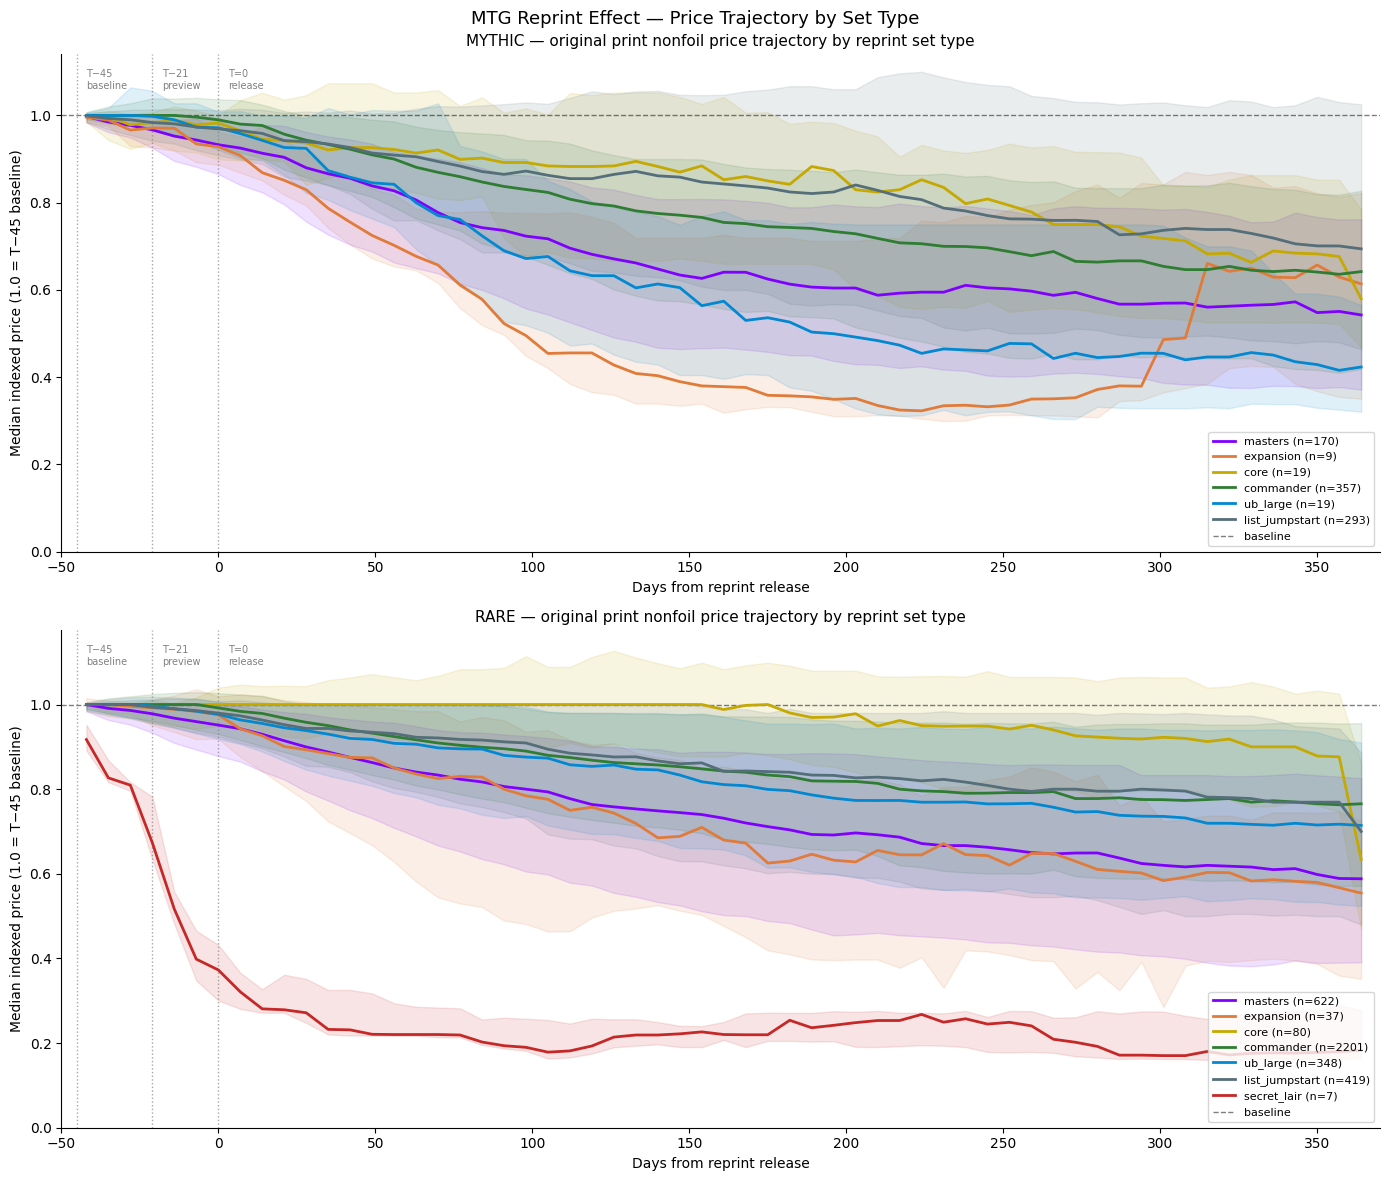

In [6]:
# Use original_print NONFOIL only for the primary trajectory
traj = windows[
    (windows['version_type'] == 'original_print') &
    (windows['finish_code'] == 'NONFOIL')
].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

for ax, rarity in zip(axes, RARITY_ORDER):
    sub = traj[traj['rarity_name'] == rarity]
    for stype in SET_TYPE_ORDER:
        bucket = sub[sub['reprint_set_type'] == stype]
        n_events = bucket['event_id'].nunique()
        if n_events < MIN_BUCKET_SIZE:
            continue
        weekly = (
            bucket.groupby('week')['indexed_price']
            .agg(median='median', p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
            .reset_index()
        )
        # Limit to T-45 → T+365 for the trajectory chart
        weekly = weekly[(weekly['week'] >= -45) & (weekly['week'] <= 365)]
        color = SET_TYPE_COLORS[stype]
        ax.plot(weekly['week'], weekly['median'], color=color, linewidth=2,
                label=f'{stype} (n={n_events})', zorder=3)
        ax.fill_between(weekly['week'], weekly['p25'], weekly['p75'],
                        color=color, alpha=0.12, zorder=2)

    ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='baseline')
    for day, label in [(-45, 'T−45\nbaseline'), (-21, 'T−21\npreview'), (0, 'T=0\nrelease')]:
        ax.axvline(day, color='gray', linestyle=':', linewidth=1, alpha=0.7)
        ax.text(day + 3, 0.97, label, fontsize=7, color='gray', va='top',
                transform=ax.get_xaxis_transform())

    ax.set_xlim(-50, 370)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Days from reprint release', fontsize=10)
    ax.set_ylabel('Median indexed price (1.0 = T−45 baseline)', fontsize=10)
    ax.set_title(f'{rarity.upper()} — original print nonfoil price trajectory by reprint set type', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('MTG Reprint Effect — Price Trajectory by Set Type', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'reprint_fig1_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4 — Price Drop Depth

Per-event metrics: how much does the original print nonfoil drop in week 1 and at its trough (T0–T90)?

Computed metrics for 4,582 events


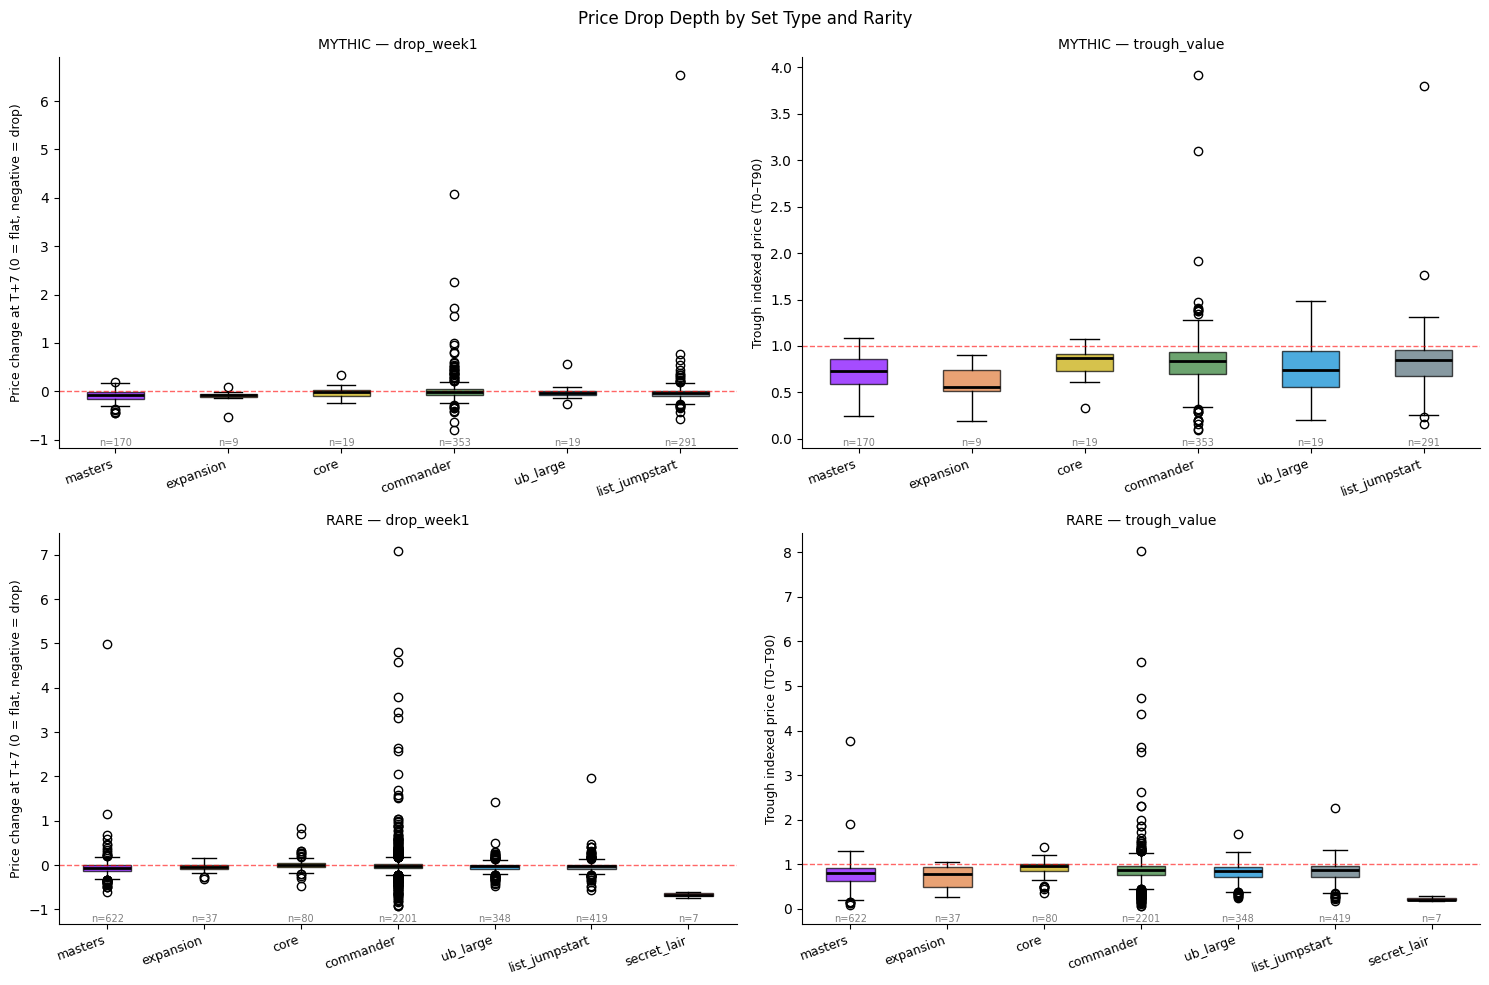


Median drop metrics by set type and rarity:


drop_week1  trough_value  trough_day
reprint_set_type rarity_name                                      
masters          mythic           -0.071         0.728        88.0
                 rare             -0.055         0.793        84.0
expansion        mythic           -0.083         0.554        90.0
                 rare             -0.043         0.788        82.0
core             mythic           -0.014         0.870        75.0
                 rare              0.000         0.952        70.5
commander        mythic           -0.014         0.835        82.0
                 rare             -0.011         0.873        75.0
ub_large         mythic           -0.035         0.741        89.0
                 rare             -0.031         0.857        77.0
list_jumpstart   mythic           -0.034         0.853        68.0
                 rare             -0.023         0.878        75.0
secret_lair      mythic            0.254         1.250        90.0
                 rare             -0.673         0.195        87.0

In [7]:
orig_nf = windows[
    (windows['version_type'] == 'original_print') &
    (windows['finish_code'] == 'NONFOIL')
].copy()

def get_price_at(grp, target_day, tolerance=7):
    nearby = grp[np.abs(grp['days_from_release'] - target_day) <= tolerance]
    return nearby['indexed_price'].median() if not nearby.empty else np.nan

metrics_rows = []
for event_id, grp in orig_nf.groupby('event_id'):
    ev = events[events['event_id'] == event_id].iloc[0]
    p_t7   = get_price_at(grp, 7)
    trough_grp = grp[(grp['days_from_release'] >= 0) & (grp['days_from_release'] <= 90)]
    trough_val = trough_grp['indexed_price'].min() if not trough_grp.empty else np.nan
    trough_day = trough_grp.loc[trough_grp['indexed_price'].idxmin(), 'days_from_release'] \
                 if not trough_grp.empty else np.nan
    p_t90  = get_price_at(grp, 90)
    p_t180 = get_price_at(grp, 180)
    p_t365 = get_price_at(grp, 365)
    p_t45_pre  = get_price_at(grp, -45)
    p_t90_pre  = get_price_at(grp, -90)
    baseline_cents = grp['baseline_cents'].median()

    metrics_rows.append({
        'event_id':             event_id,
        'card_name':            ev['card_name'],
        'unique_card_id':       ev['unique_card_id'],
        'rarity_name':          ev['rarity_name'],
        'reprint_set_type':     ev['reprint_set_type'],
        'reprint_set':          ev['reprint_set'],
        'reprint_release':      ev['reprint_release'],
        'reprint_includes_foil': grp['reprint_includes_foil'].iloc[0],
        'baseline_cents':       baseline_cents,
        'drop_week1':           (p_t7 - 1.0)   if pd.notna(p_t7)  else np.nan,
        'trough_value':         trough_val,
        'trough_day':           trough_day,
        'rebound_T90':          (p_t90  / trough_val - 1) if pd.notna(trough_val) and trough_val > 0 else np.nan,
        'rebound_T180':         (p_t180 / trough_val - 1) if pd.notna(trough_val) and trough_val > 0 else np.nan,
        'rebound_T365':         (p_t365 / trough_val - 1) if pd.notna(trough_val) and trough_val > 0 else np.nan,
        'indexed_T90':          p_t90,
        'indexed_T180':         p_t180,
        'indexed_T365':         p_t365,
        'indexed_T45_pre':      p_t45_pre,
        'indexed_T90_pre':      p_t90_pre,
    })

metrics = pd.DataFrame(metrics_rows)
print(f'Computed metrics for {len(metrics):,} events')

# Box plot: drop_week1 and trough_value by set type × rarity
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for col, (metric, label) in enumerate([
    ('drop_week1',   'Price change at T+7 (0 = flat, negative = drop)'),
    ('trough_value', 'Trough indexed price (T0–T90)')
]):
    for row, rarity in enumerate(RARITY_ORDER):
        ax = axes[row][col]
        sub = metrics[(metrics['rarity_name'] == rarity) & metrics[metric].notna()]
        order = [t for t in SET_TYPE_ORDER if (sub['reprint_set_type'] == t).sum() >= MIN_BUCKET_SIZE]
        data_groups = [sub[sub['reprint_set_type'] == t][metric].values for t in order]

        bp = ax.boxplot(data_groups, patch_artist=True, notch=False,
                        medianprops={'color': 'black', 'linewidth': 2})
        for patch, stype in zip(bp['boxes'], order):
            patch.set_facecolor(SET_TYPE_COLORS[stype])
            patch.set_alpha(0.7)

        ref_line = 0.0 if metric == 'drop_week1' else 1.0
        ax.axhline(ref_line, color='red', linestyle='--', linewidth=1, alpha=0.6)
        ax.set_xticks(range(1, len(order) + 1))
        ax.set_xticklabels(order, rotation=20, ha='right', fontsize=9)
        ax.set_ylabel(label, fontsize=9)
        ax.set_title(f'{rarity.upper()} — {metric}', fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        for i, grp_data in enumerate(data_groups):
            ymin = ax.get_ylim()[0]
            ax.text(i + 1, ymin, f'n={len(grp_data)}',
                    ha='center', fontsize=7, color='gray', va='bottom')

fig.suptitle('Price Drop Depth by Set Type and Rarity', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'reprint_fig2_drop_depth.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMedian drop metrics by set type and rarity:')
display(
    metrics.groupby(['reprint_set_type', 'rarity_name'])[['drop_week1', 'trough_value', 'trough_day']]
    .agg('median').round(3)
    .reindex([t for t in SET_TYPE_ORDER if t in metrics['reprint_set_type'].unique()], level=0)
)

## Part 5 — Rebound Analysis

Three recovery definitions:
1. **Nominal**: indexed price at T+365 ≥ 1.0 (returns to T−45 baseline).
2. **Market-adjusted**: indexed price at T+365 ≥ the control group's median indexed price at T+365  
   (control = same-rarity cards with no reprint event in [T−90, T+365]).
3. **Spread normalization**: value_retention_ratio stabilizes — covered in Part 6.

In [8]:
reprinted_ids_set = set(events['unique_card_id'])

# Pre-aggregate to weekly medians in SQL — avoids pulling 10M+ raw rows
SQL_CONTROL_AGG = """
SELECT
    DATE_TRUNC('week', ppd.price_date)::date AS week_start,
    cv.unique_card_id::text,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY ppd.list_avg_cents) AS median_cents
FROM pricing.print_price_daily ppd
JOIN card_catalog.card_version cv  ON cv.card_version_id = ppd.card_version_id
JOIN card_catalog.card_finished cf ON cf.finish_id = ppd.finish_id
JOIN card_catalog.rarities_ref r   ON r.rarity_id = cv.rarity_id
JOIN pricing.price_source ps       ON ps.source_id = ppd.source_id
JOIN pricing.transaction_type tt   ON tt.transaction_type_id = ppd.transaction_type_id
JOIN pricing.card_condition cc     ON cc.condition_id = ppd.condition_id
JOIN card_catalog.language_ref lr  ON lr.language_id = ppd.language_id
WHERE r.rarity_name IN ('mythic', 'rare')
  AND NOT cv.is_digital
  AND cf.code = 'NONFOIL'
  AND ps.code IN ('tcg', 'mtgstocks')
  AND tt.transaction_type_code = 'sell'
  AND cc.code = 'NM'
  AND lr.language_code = 'en'
  AND ppd.list_avg_cents IS NOT NULL
  AND ppd.list_avg_cents > 0
  AND cv.unique_card_id != ALL(%(reprinted_ids)s::uuid[])
GROUP BY 1, 2
"""

PARQUET_CTRL = DATA_DIR / 'reprint_control_index.parquet'
if REFRESH or not PARQUET_CTRL.exists():
    print('Querying control group prices (non-reprinted cards, weekly aggregates)...')
    ctrl_raw = query_to_df(SQL_CONTROL_AGG, {'reprinted_ids': list(reprinted_ids_set)})
    ctrl_raw['week_start']   = pd.to_datetime(ctrl_raw['week_start'])
    ctrl_raw['median_cents'] = pd.to_numeric(ctrl_raw['median_cents'])
    ctrl_raw.to_parquet(PARQUET_CTRL, index=False)
    print(f'  Saved {len(ctrl_raw):,} weekly rows, {ctrl_raw["unique_card_id"].nunique():,} control cards')
else:
    ctrl_raw = pd.read_parquet(PARQUET_CTRL)
    # Invalidate old daily-format cache (has 'price_date' column instead of 'week_start')
    if 'price_date' in ctrl_raw.columns:
        print('Old daily-format cache detected — re-fetching weekly aggregates.')
        PARQUET_CTRL.unlink()
        ctrl_raw = query_to_df(SQL_CONTROL_AGG, {'reprinted_ids': list(reprinted_ids_set)})
        ctrl_raw['week_start']   = pd.to_datetime(ctrl_raw['week_start'])
        ctrl_raw['median_cents'] = pd.to_numeric(ctrl_raw['median_cents'])
        ctrl_raw.to_parquet(PARQUET_CTRL, index=False)
        print(f'  Re-saved {len(ctrl_raw):,} weekly rows, {ctrl_raw["unique_card_id"].nunique():,} control cards')
    else:
        print(f'Loaded {len(ctrl_raw):,} weekly control rows, {ctrl_raw["unique_card_id"].nunique():,} cards')

def get_market_index(release_date, b_start_days=-52, b_end_days=-38, horizons=(90, 180, 365)):
    """Median indexed price for control cards at each horizon, relative to release_date.
    Operates on weekly-aggregated ctrl_raw (columns: week_start, median_cents)."""
    b_start = release_date + pd.Timedelta(days=b_start_days)
    b_end   = release_date + pd.Timedelta(days=b_end_days)
    baseline_slice = ctrl_raw[
        (ctrl_raw['week_start'] >= b_start) &
        (ctrl_raw['week_start'] <= b_end)
    ]
    ctrl_baselines = baseline_slice.groupby('unique_card_id')['median_cents'].median()
    if ctrl_baselines.empty:
        return {h: np.nan for h in horizons}
    result = {}
    for h in horizons:
        h_start = release_date + pd.Timedelta(days=h - 14)
        h_end   = release_date + pd.Timedelta(days=h + 14)
        h_slice = ctrl_raw[
            (ctrl_raw['week_start'] >= h_start) &
            (ctrl_raw['week_start'] <= h_end) &
            (ctrl_raw['unique_card_id'].isin(ctrl_baselines.index))
        ]
        if h_slice.empty:
            result[h] = np.nan
            continue
        h_medians = h_slice.groupby('unique_card_id')['median_cents'].median()
        indexed = h_medians / ctrl_baselines.reindex(h_medians.index)
        result[h] = indexed.median()
    return result

# Compute per unique release date — not per event (11k events → ~200 unique dates)
unique_release_dates = events['reprint_release'].unique()
print(f'Computing market index for {len(unique_release_dates)} unique release dates ' +
      f'(covering {len(events):,} events)...')

date_to_market_index = {}
for i, rel_date in enumerate(unique_release_dates):
    date_to_market_index[rel_date] = get_market_index(rel_date)
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(unique_release_dates)} dates', end='\r')

market_indices = {
    ev['event_id']: date_to_market_index[ev['reprint_release']]
    for _, ev in events.iterrows()
}
print(f'\nDone. Sample: {list(market_indices.items())[:2]}')


Querying control group prices (non-reprinted cards, weekly aggregates)...
  Saved 1,379,929 weekly rows, 8,112 control cards
Computing market index for 147 unique release dates (covering 11,518 events)...
  140/147 dates
Done. Sample: [(0, {90: nan, 180: nan, 365: nan}), (1, {90: nan, 180: nan, 365: nan})]


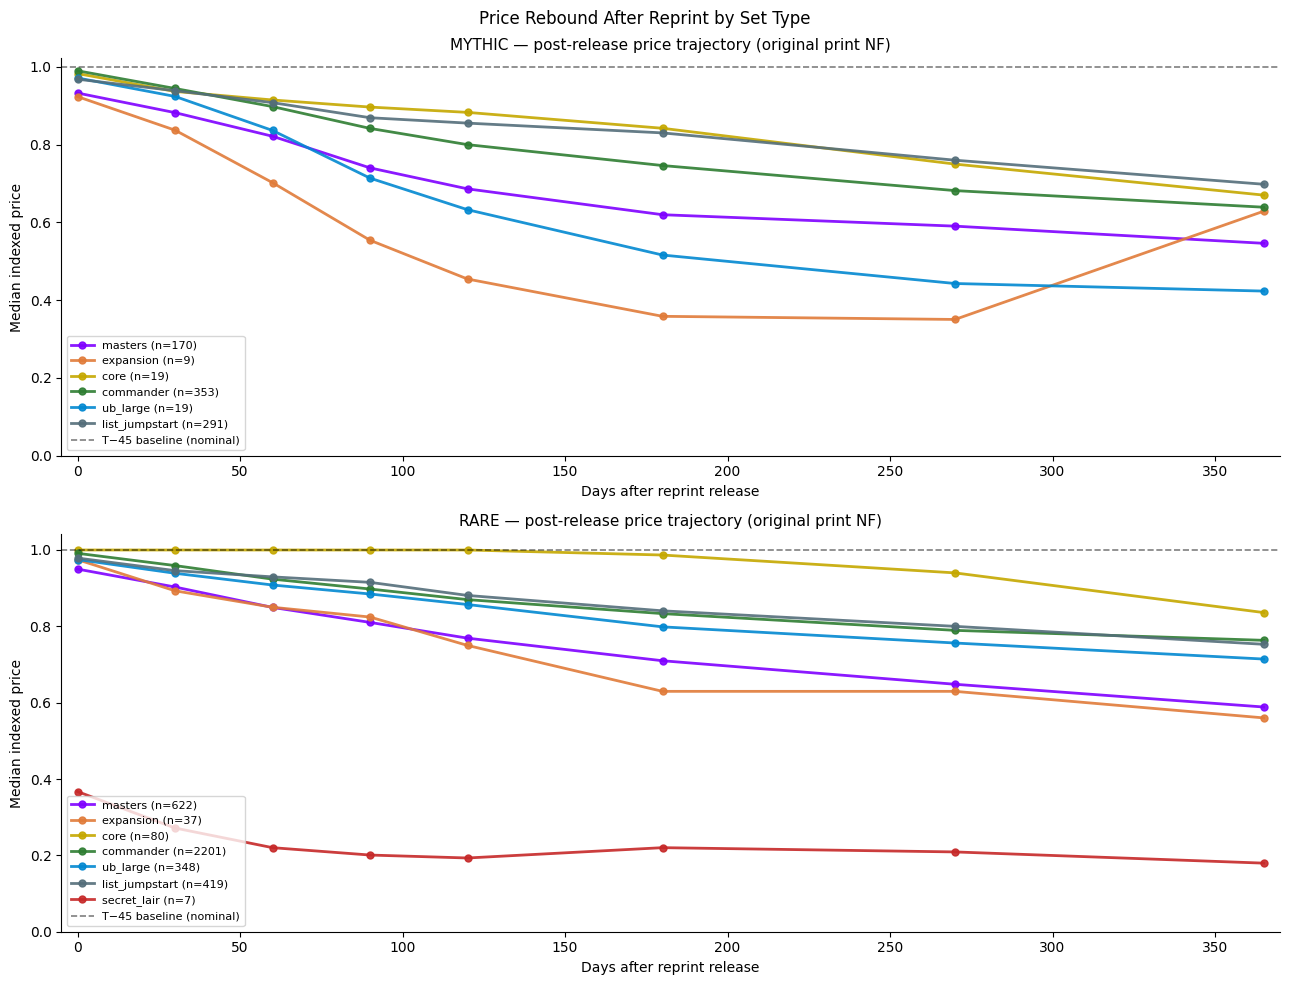


Recovery rates by set type and rarity (events with T+365 data):


nominal_recover_% mkt_adj_recover_%
reprint_set_type rarity_name                                    
masters          mythic                0.08284          0.100592
                 rare                 0.109677          0.132258
expansion        mythic               0.111111          0.111111
                 rare                 0.108108          0.108108
core             mythic               0.105263          0.105263
                 rare                   0.2875            0.2875
commander        mythic                0.10101          0.117845
                 rare                 0.192222          0.233889
ub_large         mythic                    0.0          0.058824
                 rare                 0.159159          0.207207
list_jumpstart   mythic                0.27451          0.303922
                 rare                 0.198864          0.232955
secret_lair      mythic                    0.0               1.0
                 rare                      0.0               0.0

In [9]:
# Add market-adjusted recovery flags to metrics
metrics['market_index_T90']  = metrics['event_id'].map(lambda eid: market_indices.get(eid, {}).get(90, np.nan))
metrics['market_index_T180'] = metrics['event_id'].map(lambda eid: market_indices.get(eid, {}).get(180, np.nan))
metrics['market_index_T365'] = metrics['event_id'].map(lambda eid: market_indices.get(eid, {}).get(365, np.nan))

# Preserve NaN for events without T+N data so downstream filters work correctly
metrics['nominal_recovery_T365']   = metrics['indexed_T365'].apply(lambda x: (x >= 1.0) if pd.notna(x) else np.nan)
metrics['mktadj_recovery_T365']    = metrics.apply(
    lambda r: (r['indexed_T365'] >= r['market_index_T365'])
              if pd.notna(r['indexed_T365']) and pd.notna(r['market_index_T365']) else np.nan, axis=1)
metrics['nominal_recovery_T180']   = metrics['indexed_T180'].apply(lambda x: (x >= 1.0) if pd.notna(x) else np.nan)
metrics['mktadj_recovery_T180']    = metrics.apply(
    lambda r: (r['indexed_T180'] >= r['market_index_T180'])
              if pd.notna(r['indexed_T180']) and pd.notna(r['market_index_T180']) else np.nan, axis=1)

# Save complete metrics (recovery flags computed here, not in Part 4)
metrics.to_parquet(DATA_DIR / 'reprint_event_metrics.parquet', index=False)

# Rebound line chart by set type + rarity
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

horizons_days = [0, 30, 60, 90, 120, 180, 270, 365]

for ax, rarity in zip(axes, RARITY_ORDER):
    sub_win = windows[
        (windows['version_type'] == 'original_print') &
        (windows['finish_code'] == 'NONFOIL') &
        (windows['rarity_name'] == rarity) &
        (windows['days_from_release'] >= 0)
    ]
    for stype in SET_TYPE_ORDER:
        bucket = sub_win[sub_win['reprint_set_type'] == stype]
        n = bucket['event_id'].nunique()
        if n < MIN_BUCKET_SIZE:
            continue
        pts = []
        for d in horizons_days:
            near = bucket[np.abs(bucket['days_from_release'] - d) <= 7]
            pts.append(near['indexed_price'].median() if not near.empty else np.nan)
        ax.plot(horizons_days, pts, marker='o', markersize=5, linewidth=2,
                color=SET_TYPE_COLORS[stype], label=f'{stype} (n={n})', alpha=0.9)

    ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.5, label='T−45 baseline (nominal)')
    ax.set_xlim(-5, 370)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Days after reprint release', fontsize=10)
    ax.set_ylabel('Median indexed price', fontsize=10)
    ax.set_title(f'{rarity.upper()} — post-release price trajectory (original print NF)', fontsize=11)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Price Rebound After Reprint by Set Type', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'reprint_fig3_rebound.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRecovery rates by set type and rarity (events with T+365 data):')
has_t365 = metrics[metrics['indexed_T365'].notna()]
display(
    has_t365.groupby(['reprint_set_type', 'rarity_name'])[
        ['nominal_recovery_T365', 'mktadj_recovery_T365']
    ].agg('mean').round(2)
    .rename(columns={'nominal_recovery_T365': 'nominal_recover_%', 'mktadj_recovery_T365': 'mkt_adj_recover_%'})
    .reindex([t for t in SET_TYPE_ORDER if t in has_t365['reprint_set_type'].unique()], level=0)
)

## Part 6 — Original Print vs Reprint Version

For events with price data for both versions: does the original print recover better?  
Also: does the original foil's premium over the original nonfoil *expand* when the nonfoil gets reprinted?

Events with both original + reprint NF price data: 45


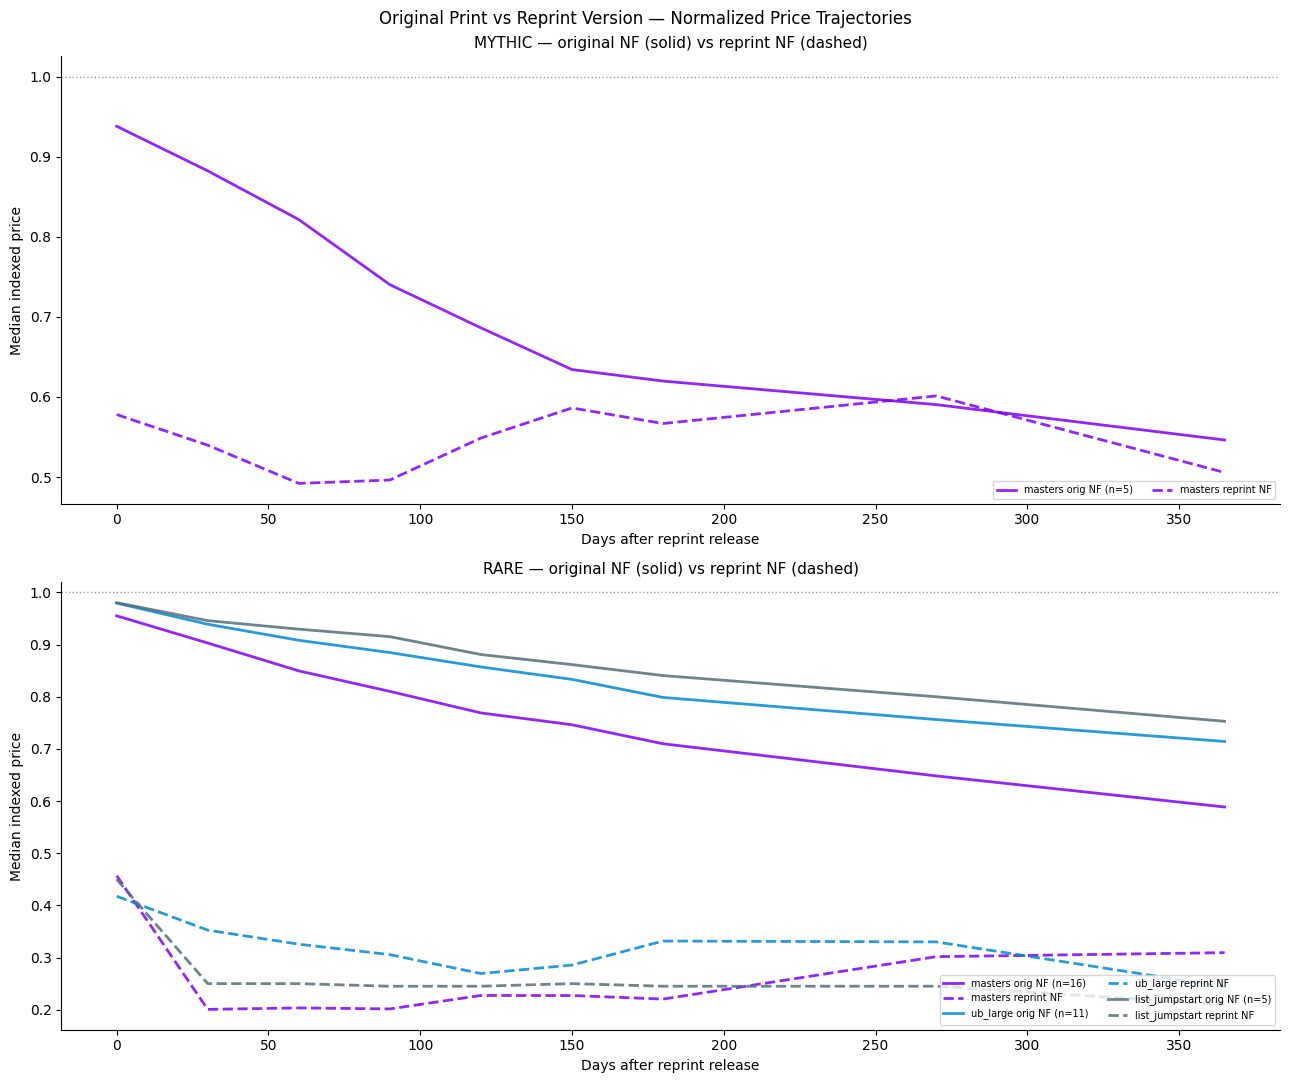


Median value_retention_ratio (original NF / reprint NF) by set type × rarity × horizon:


horizon                        30    90    180   365
reprint_set_type rarity_name                        
masters          mythic       1.99  1.79  1.51  1.70
                 rare         5.06  3.24  3.06  2.63
expansion        mythic       2.32  1.86  1.69  1.38
commander        mythic       9.79  7.92  6.89  5.19
ub_large         rare         2.30  2.04  1.78  1.48
list_jumpstart   mythic       2.20  2.06  1.96  2.55
                 rare         3.77  3.85  3.77  4.14


Median foil multiplier on original print (foil/NF ratio) over time:


horizon                            -45    0     90    180   365
reprint_includes_foil rarity_name                              
False                 mythic        1.0  1.01  1.14  1.23  1.27
                      rare          1.0  1.01  1.09  1.13  1.18
True                  mythic        1.0  1.00  1.13  1.11  1.01
                      rare          1.0  1.00  1.07  1.09  1.06

In [10]:
# value_retention_ratio = original_nf indexed / reprint_nf indexed at same time step
# Restricted to events where BOTH versions have price data

orig_nf_w    = windows[(windows['version_type'] == 'original_print') & (windows['finish_code'] == 'NONFOIL')]
reprint_nf_w = windows[(windows['version_type'] == 'reprint_version') & (windows['finish_code'] == 'NONFOIL')]
orig_foil_w  = windows[(windows['version_type'] == 'original_print') & (windows['finish_code'] == 'FOIL')]

# Events with both original and reprint NF data
both_events = set(orig_nf_w['event_id']) & set(reprint_nf_w['event_id'])
print(f'Events with both original + reprint NF price data: {len(both_events):,}')

# Pre-group by event_id for O(1) lookup
orig_nf_by_eid    = {eid: grp for eid, grp in orig_nf_w.groupby('event_id')}
reprint_nf_by_eid = {eid: grp for eid, grp in reprint_nf_w.groupby('event_id')}
orig_foil_by_eid  = {eid: grp for eid, grp in orig_foil_w.groupby('event_id')}

# Compute value_retention_ratio at T+30/90/180/365
retention_rows = []
for eid in both_events:
    ev_meta = events[events['event_id'] == eid].iloc[0]
    o_grp = orig_nf_by_eid[eid]
    r_grp = reprint_nf_by_eid[eid]
    for horizon in [30, 90, 180, 365]:
        orig_pt = o_grp[np.abs(o_grp['days_from_release'] - horizon) <= 7]['indexed_price'].median()
        repr_pt = r_grp[np.abs(r_grp['days_from_release'] - horizon) <= 7]['indexed_price'].median()
        if pd.isna(orig_pt) or pd.isna(repr_pt) or repr_pt <= 0:
            continue
        foil_flag = o_grp['reprint_includes_foil'].iloc[0]
        retention_rows.append({
            'event_id':              eid,
            'rarity_name':           ev_meta['rarity_name'],
            'reprint_set_type':      ev_meta['reprint_set_type'],
            'reprint_includes_foil': foil_flag,
            'horizon':               horizon,
            'orig_indexed':          orig_pt,
            'reprint_indexed':       repr_pt,
            'value_retention_ratio': orig_pt / repr_pt,
        })

retention = pd.DataFrame(retention_rows)

# foil_multiplier_original: original foil / original NF over time
foil_mult_rows = []
foil_events = set(orig_foil_by_eid) & set(orig_nf_by_eid)
for eid in foil_events:
    o_nf_grp   = orig_nf_by_eid[eid]
    o_foil_grp = orig_foil_by_eid[eid]
    ev_meta    = events[events['event_id'] == eid].iloc[0]
    for horizon in [-45, 0, 90, 180, 365]:
        foil_pt = o_foil_grp[np.abs(o_foil_grp['days_from_release'] - horizon) <= 7]['indexed_price'].median()
        nf_pt   = o_nf_grp[np.abs(o_nf_grp['days_from_release'] - horizon) <= 7]['indexed_price'].median()
        if pd.isna(foil_pt) or pd.isna(nf_pt) or nf_pt <= 0:
            continue
        foil_mult_rows.append({
            'event_id':              eid,
            'rarity_name':           ev_meta['rarity_name'],
            'reprint_set_type':      ev_meta['reprint_set_type'],
            'reprint_includes_foil': o_foil_grp['reprint_includes_foil'].iloc[0],
            'horizon':               horizon,
            'foil_multiplier':       foil_pt / nf_pt,
        })

foil_mults = pd.DataFrame(foil_mult_rows)

# Panel A: dual-line original NF vs reprint NF by set type
fig, axes = plt.subplots(2, 1, figsize=(13, 11))

horizons_plot = [0, 30, 60, 90, 120, 150, 180, 270, 365]

for ax, rarity in zip(axes, RARITY_ORDER):
    orig_sub    = orig_nf_w[(orig_nf_w['rarity_name'] == rarity) & (orig_nf_w['days_from_release'] >= -10)]
    reprint_sub = reprint_nf_w[(reprint_nf_w['rarity_name'] == rarity) & (reprint_nf_w['days_from_release'] >= -10)]

    for stype in SET_TYPE_ORDER:
        o_bucket = orig_sub[orig_sub['reprint_set_type'] == stype]
        r_bucket = reprint_sub[reprint_sub['reprint_set_type'] == stype]
        n = len(set(o_bucket['event_id']) & set(r_bucket['event_id']))
        if n < MIN_BUCKET_SIZE:
            continue
        color = SET_TYPE_COLORS[stype]
        for bucket, ls, suffix in [(o_bucket, '-', 'orig NF'), (r_bucket, '--', 'reprint NF')]:
            pts = [bucket[np.abs(bucket['days_from_release'] - d) <= 7]['indexed_price'].median()
                   for d in horizons_plot]
            ax.plot(horizons_plot, pts, linestyle=ls, linewidth=2, color=color,
                    label=f'{stype} {suffix} (n={n})' if suffix == 'orig NF' else f'{stype} reprint NF',
                    alpha=0.85)

    ax.axhline(1.0, color='black', linestyle=':', linewidth=1, alpha=0.4)
    ax.set_xlabel('Days after reprint release', fontsize=10)
    ax.set_ylabel('Median indexed price', fontsize=10)
    ax.set_title(f'{rarity.upper()} — original NF (solid) vs reprint NF (dashed)', fontsize=11)
    ax.legend(fontsize=7, ncol=2, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Original Print vs Reprint Version — Normalized Price Trajectories', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'reprint_fig4_orig_vs_reprint.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMedian value_retention_ratio (original NF / reprint NF) by set type × rarity × horizon:')
display(
    retention.groupby(['reprint_set_type', 'rarity_name', 'horizon'])['value_retention_ratio']
    .median().unstack('horizon').round(2)
    .reindex([t for t in SET_TYPE_ORDER if t in retention['reprint_set_type'].unique()], level=0)
)

if not foil_mults.empty:
    print('\nMedian foil multiplier on original print (foil/NF ratio) over time:')
    display(
        foil_mults.groupby(['reprint_includes_foil', 'rarity_name', 'horizon'])['foil_multiplier']
        .median().unstack('horizon').round(2)
    )

## Part 7 — Rarity Effect

Are mythics more resilient to reprints than rares?  
Side-by-side comparison of drop depth, trough, and T+365 recovery rate.

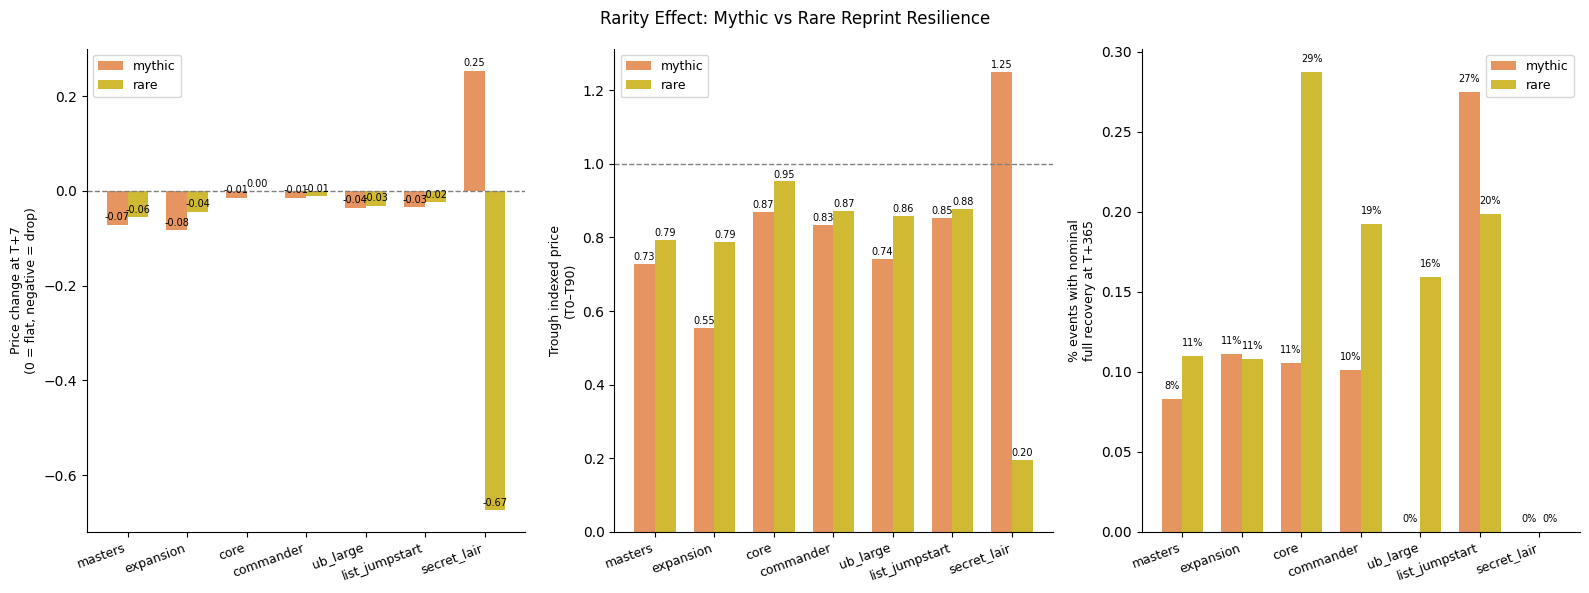

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metric_configs = [
    ('drop_week1',            'Price change at T+7\n(0 = flat, negative = drop)', True),
    ('trough_value',          'Trough indexed price\n(T0–T90)',                   True),
    ('nominal_recovery_T365', '% events with nominal\nfull recovery at T+365',    False),
]

for ax, (metric, ylabel, is_box) in zip(axes, metric_configs):
    valid = metrics[metrics[metric].notna()]
    order = [t for t in SET_TYPE_ORDER if (valid['reprint_set_type'] == t).sum() >= MIN_BUCKET_SIZE]

    x = np.arange(len(order))
    width = 0.35

    for i, rarity in enumerate(RARITY_ORDER):
        sub = valid[valid['rarity_name'] == rarity]
        if is_box:
            vals = [sub[sub['reprint_set_type'] == t][metric].median() for t in order]
            bars = ax.bar(x + (i - 0.5) * width, vals, width,
                          color=RARITY_COLORS[rarity], alpha=0.8, label=rarity)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=7)
        else:
            vals = [sub[sub['reprint_set_type'] == t][metric].mean() for t in order]
            bars = ax.bar(x + (i - 0.5) * width, vals, width,
                          color=RARITY_COLORS[rarity], alpha=0.8, label=rarity)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                        f'{v:.0%}', ha='center', va='bottom', fontsize=7)

    if metric in ('drop_week1', 'trough_value'):
        ax.axhline(1.0 if metric == 'trough_value' else 0.0, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Rarity Effect: Mythic vs Rare Reprint Resilience', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'reprint_fig5_rarity.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 8 — Pre-Announcement Drift: Information Leakage Investigation

**Hypothesis:** Cards with advance-knowledge holders (distributors, WotC employees, early preview partners)
may show abnormal price declines in the `[T−90, T−45]` window — *before* any public announcement.

**Method:** Compare reprinted cards' `[T−90, T−45]` drift to a control group of non-reprinted
same-rarity cards over the same calendar period. A strongly negative `abnormal_drift` is
*consistent with* leakage but not proof — organic demand decline and speculation can also explain it.

**Scope:** Only cards with baseline price > $15 (1500 cents) — leakage incentives don't exist for cheap cards.

In [12]:
# drift_T90_T45 per event: (indexed_price_at_T-45) / (indexed_price_at_T-90) - 1
# We already have indexed_T45_pre and indexed_T90_pre in metrics

drift = metrics[
    metrics['baseline_cents'] >= LEAKAGE_PRICE_THRESHOLD  # > $15
].copy()
drift = drift[drift['indexed_T45_pre'].notna() & drift['indexed_T90_pre'].notna()].copy()

drift['drift_T90_T45'] = drift['indexed_T45_pre'] / drift['indexed_T90_pre'] - 1

def control_drift_for_event(release_date):
    """Market drift in [T-90, T-45] for control (non-reprinted) cards.
    Uses weekly-aggregated ctrl_raw (columns: week_start, median_cents)."""
    t90_start = release_date + pd.Timedelta(days=-97)
    t90_end   = release_date + pd.Timedelta(days=-83)
    t45_start = release_date + pd.Timedelta(days=-52)
    t45_end   = release_date + pd.Timedelta(days=-38)

    ctrl_t90 = ctrl_raw[
        (ctrl_raw['week_start'] >= t90_start) & (ctrl_raw['week_start'] <= t90_end)
    ].groupby('unique_card_id')['median_cents'].median()

    ctrl_t45 = ctrl_raw[
        (ctrl_raw['week_start'] >= t45_start) & (ctrl_raw['week_start'] <= t45_end)
    ].groupby('unique_card_id')['median_cents'].median()

    common = ctrl_t90.index.intersection(ctrl_t45.index)
    if len(common) < 10:
        return np.nan
    ratios = ctrl_t45.loc[common] / ctrl_t90.loc[common] - 1
    return ratios.median()

print('Computing control drift per event...')
drift['control_drift'] = drift['reprint_release'].map(control_drift_for_event)
drift['abnormal_drift'] = drift['drift_T90_T45'] - drift['control_drift']

print(f'\nEvents analyzed (price > $15 at baseline): {len(drift):,}')
print(f'Mean drift_T90_T45:   {drift["drift_T90_T45"].mean():.3f}')
print(f'Mean abnormal_drift:  {drift["abnormal_drift"].mean():.3f}')

# t-test: is mean abnormal_drift < 0?
t_stat, p_val = stats.ttest_1samp(drift['abnormal_drift'].dropna(), 0)
print(f'\nOne-sample t-test (H0: abnormal_drift = 0):')
print(f'  t = {t_stat:.3f}, p = {p_val:.4f}')
print(f'  {"Reject H0: mean abnormal drift is statistically < 0" if p_val < 0.05 and t_stat < 0 else "Cannot reject H0"}')

# Leakage candidates: bottom 10th percentile of abnormal_drift
p10 = drift['abnormal_drift'].quantile(0.10)
candidates = drift[drift['abnormal_drift'] <= p10].sort_values('abnormal_drift')
print(f'\nLeakage candidates (bottom 10th percentile, abnormal_drift ≤ {p10:.3f}):')
display(candidates[['card_name', 'reprint_set', 'reprint_set_type', 'rarity_name',
                     'baseline_cents', 'drift_T90_T45', 'control_drift', 'abnormal_drift']]
        .assign(baseline_usd=lambda d: d['baseline_cents'] / 100)
        .drop(columns='baseline_cents')
        .round(3))


Computing control drift per event...

Events analyzed (price > $15 at baseline): 492
Mean drift_T90_T45:   0.024
Mean abnormal_drift:  0.037

One-sample t-test (H0: abnormal_drift = 0):
  t = 2.471, p = 0.0138
  Cannot reject H0

Leakage candidates (bottom 10th percentile, abnormal_drift ≤ -0.098):


,card_name,reprint_set,reprint_set_type,rarity_name,drift_T90_T45,control_drift,abnormal_drift,baseline_usd
3288,Who's That Praetor?,mb2,masters,rare,-0.667,-0.010,-0.657,199.980
3158,Mana Short,mb2,masters,rare,-0.609,-0.010,-0.599,696.410
3352,Inkshield,dsc,commander,rare,-0.482,0.000,-0.482,15.000
3298,Zombie Master,mb2,masters,rare,-0.440,-0.010,-0.430,375.000
3164,Meekstone,mb2,masters,rare,-0.413,-0.010,-0.403,2344.000
1835,Ohran Frostfang,cmm,masters,rare,-0.356,-0.037,-0.318,15.990
275,Wrenn and Seven,dbl,list_jumpstart,mythic,-0.314,-0.008,-0.306,20.170
4143,Godless Shrine,eoe,ub_large,rare,-0.277,0.000,-0.277,16.260
3167,Mindbreak Trap,mb2,masters,mythic,-0.273,-0.010,-0.263,39.650
2213,Kinsbaile Cavalier,spg,list_jumpstart,mythic,-0.253,-0.022,-0.231,19.490


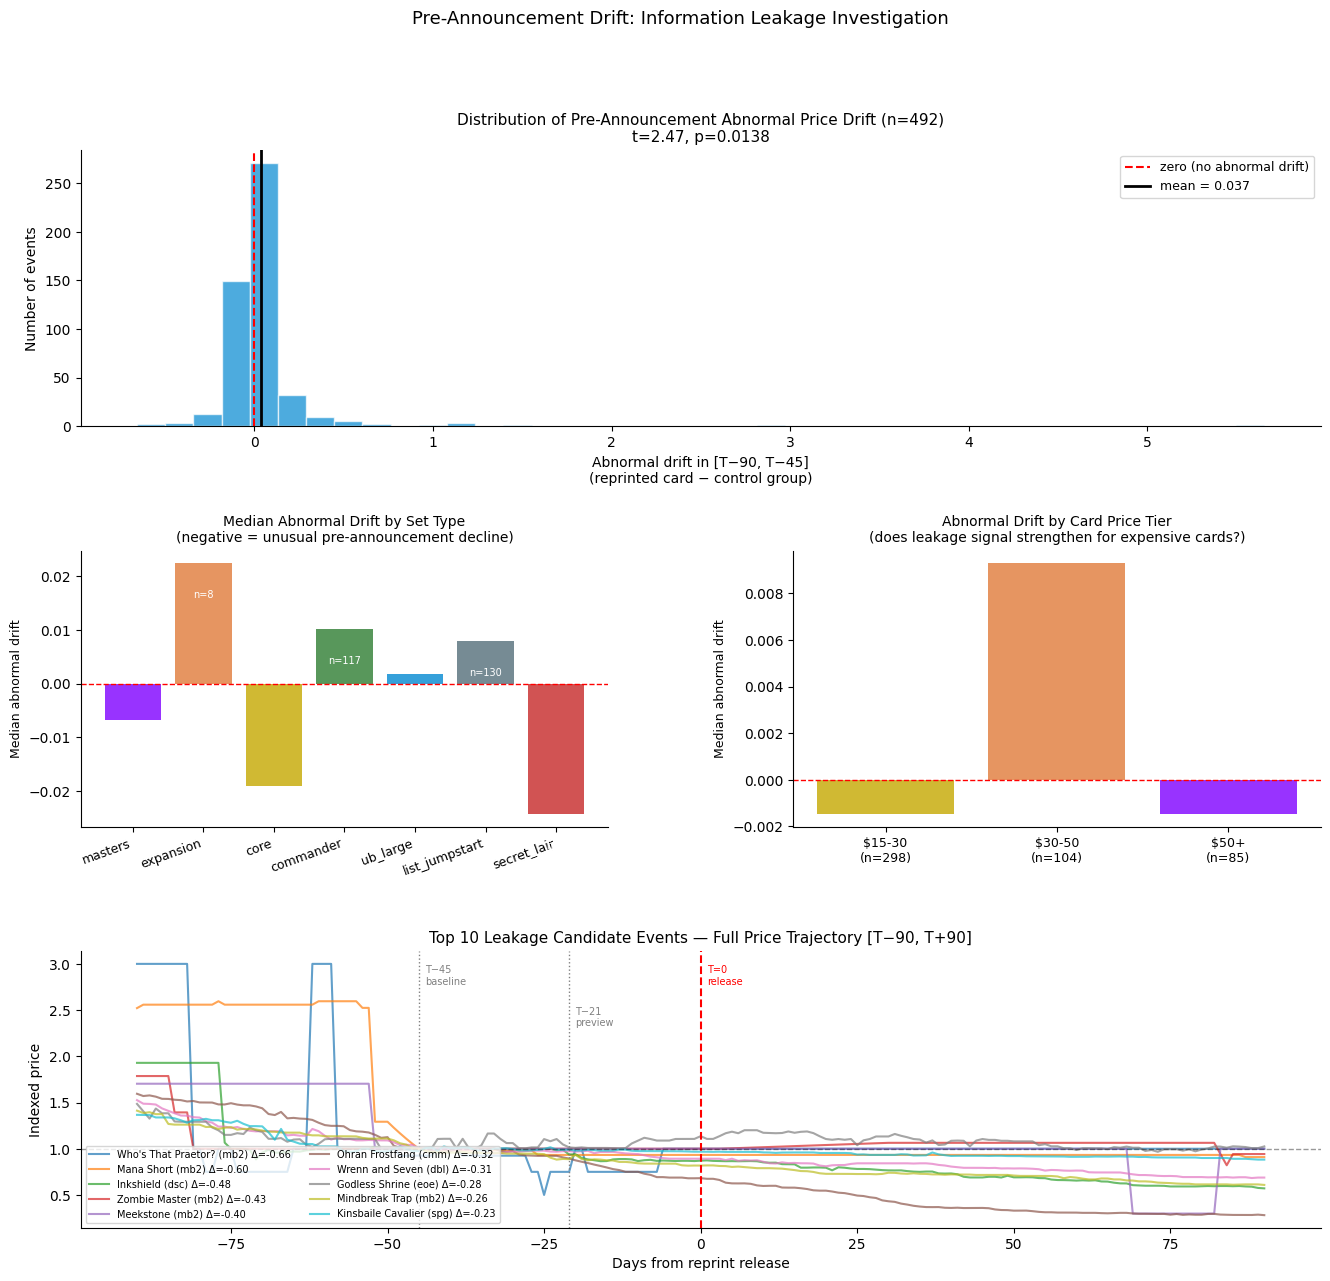

In [13]:
fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)

# Panel A: Histogram of abnormal_drift
ax_hist = fig.add_subplot(gs[0, :])
ax_hist.hist(drift['abnormal_drift'].dropna(), bins=40, color='#0288d1', alpha=0.7, edgecolor='white')
ax_hist.axvline(0, color='red', linestyle='--', linewidth=1.5, label='zero (no abnormal drift)')
ax_hist.axvline(drift['abnormal_drift'].mean(), color='black', linewidth=2,
                label=f'mean = {drift["abnormal_drift"].mean():.3f}')
ax_hist.set_xlabel('Abnormal drift in [T−90, T−45]\n(reprinted card − control group)', fontsize=10)
ax_hist.set_ylabel('Number of events', fontsize=10)
ax_hist.set_title(f'Distribution of Pre-Announcement Abnormal Price Drift (n={len(drift.dropna(subset=["abnormal_drift"]))})\n'
                  f't={t_stat:.2f}, p={p_val:.4f}', fontsize=11)
ax_hist.legend(fontsize=9)
ax_hist.spines['top'].set_visible(False)
ax_hist.spines['right'].set_visible(False)

# Panel B: Median abnormal_drift by set type
ax_bar = fig.add_subplot(gs[1, 0])
stype_drift = (
    drift.groupby('reprint_set_type')['abnormal_drift']
    .agg(median='median', n='count')
    .reindex([t for t in SET_TYPE_ORDER if t in drift['reprint_set_type'].unique()])
)
colors = [SET_TYPE_COLORS[t] for t in stype_drift.index]
bars = ax_bar.bar(range(len(stype_drift)), stype_drift['median'].values, color=colors, alpha=0.8)
ax_bar.axhline(0, color='red', linestyle='--', linewidth=1)
ax_bar.set_xticks(range(len(stype_drift)))
ax_bar.set_xticklabels(stype_drift.index, rotation=20, ha='right', fontsize=9)
ax_bar.set_ylabel('Median abnormal drift', fontsize=9)
ax_bar.set_title('Median Abnormal Drift by Set Type\n(negative = unusual pre-announcement decline)', fontsize=10)
for bar, (stype, row) in zip(bars, stype_drift.iterrows()):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.005,
                f'n={int(row["n"])}', ha='center', va='top', fontsize=7, color='white')
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# Panel B2: By price tier ($15-30 vs $30-50 vs $50+)
ax_tier = fig.add_subplot(gs[1, 1])
drift['price_tier'] = pd.cut(
    drift['baseline_cents'],
    bins=[1500, 3000, 5000, 1e9],
    labels=['$15-30', '$30-50', '$50+']
)
tier_drift = drift.groupby('price_tier', observed=True)['abnormal_drift'].agg(median='median', n='count')
ax_tier.bar(range(len(tier_drift)), tier_drift['median'].values,
            color=['#c5a800', '#e07b39', '#7f00ff'], alpha=0.8)
ax_tier.axhline(0, color='red', linestyle='--', linewidth=1)
ax_tier.set_xticks(range(len(tier_drift)))
ax_tier.set_xticklabels([f'{t}\n(n={int(r["n"])})' for t, r in tier_drift.iterrows()], fontsize=9)
ax_tier.set_ylabel('Median abnormal drift', fontsize=9)
ax_tier.set_title('Abnormal Drift by Card Price Tier\n(does leakage signal strengthen for expensive cards?)', fontsize=10)
ax_tier.spines['top'].set_visible(False)
ax_tier.spines['right'].set_visible(False)

# Panel C: Full [T-90, T+90] trajectories for top 10 leakage candidates
ax_lk = fig.add_subplot(gs[2, :])
top10 = candidates.head(10)
windows_by_eid = {eid: grp for eid, grp in windows.groupby('event_id')}
for _, ev_row in top10.iterrows():
    eid = ev_row['event_id']
    card_win_all = windows_by_eid.get(eid)
    if card_win_all is None:
        continue
    card_win = card_win_all[
        (card_win_all['version_type'] == 'original_print') &
        (card_win_all['finish_code'] == 'NONFOIL') &
        (card_win_all['days_from_release'] >= -90) &
        (card_win_all['days_from_release'] <= 90)
    ].sort_values('days_from_release')
    if card_win.empty:
        continue
    label = f"{ev_row['card_name']} ({ev_row['reprint_set']}) Δ={ev_row['abnormal_drift']:.2f}"
    ax_lk.plot(card_win['days_from_release'], card_win['indexed_price'],
               linewidth=1.5, alpha=0.7, label=label)

ax_lk.axvline(-45, color='gray', linestyle=':', linewidth=1)
ax_lk.axvline(-21, color='gray', linestyle=':', linewidth=1)
ax_lk.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax_lk.text(-44, 0.95, 'T−45\nbaseline', fontsize=7, color='gray', va='top',
           transform=ax_lk.get_xaxis_transform())
ax_lk.text(-20, 0.80, 'T−21\npreview', fontsize=7, color='gray', va='top',
           transform=ax_lk.get_xaxis_transform())
ax_lk.text(1, 0.95, 'T=0\nrelease', fontsize=7, color='red', va='top',
           transform=ax_lk.get_xaxis_transform())
ax_lk.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.4)
ax_lk.set_xlabel('Days from reprint release', fontsize=10)
ax_lk.set_ylabel('Indexed price', fontsize=10)
ax_lk.set_title('Top 10 Leakage Candidate Events — Full Price Trajectory [T−90, T+90]', fontsize=11)
ax_lk.legend(fontsize=7, loc='lower left', ncol=2)
ax_lk.spines['top'].set_visible(False)
ax_lk.spines['right'].set_visible(False)

fig.suptitle('Pre-Announcement Drift: Information Leakage Investigation', fontsize=13)
plt.savefig(DATA_DIR / 'reprint_fig6_leakage.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 9 — Conclusions

Synthesis of all findings.

In [14]:
print('=' * 65)
print('MTG REPRINT EFFECT ANALYSIS — FINDINGS SUMMARY')
print('=' * 65)
print()

# 1. Drop depth table
print('── Drop Depth (median, original print NF) ──')
drop_summary = (
    metrics.groupby(['reprint_set_type', 'rarity_name'])
    [['drop_week1', 'trough_value', 'trough_day']]
    .median().round(3)
    .reindex([t for t in SET_TYPE_ORDER if t in metrics['reprint_set_type'].unique()], level=0)
)
display(drop_summary)

# 2. Recovery table
print('\n── Recovery Rates (events with T+365 data) ──')
has_t365 = metrics[metrics['indexed_T365'].notna()]
rec_summary = (
    has_t365.groupby(['reprint_set_type', 'rarity_name'])
    [['nominal_recovery_T365', 'mktadj_recovery_T365']]
    .mean().round(2)
    .rename(columns={
        'nominal_recovery_T365': 'nominal_recover',
        'mktadj_recovery_T365':  'mkt_adj_recover',
    })
    .reindex([t for t in SET_TYPE_ORDER if t in has_t365['reprint_set_type'].unique()], level=0)
)
display(rec_summary)

# 3. Original premium
print('\n── Original Print Premium at T+365 (orig NF / reprint NF) ──')
ret_t365 = retention[retention['horizon'] == 365]
if not ret_t365.empty:
    display(
        ret_t365.groupby(['reprint_set_type', 'rarity_name'])['value_retention_ratio']
        .median().round(2).rename('orig_premium_over_reprint')
        .reset_index().pivot(index='reprint_set_type', columns='rarity_name', values='orig_premium_over_reprint')
        .reindex([t for t in SET_TYPE_ORDER if t in ret_t365['reprint_set_type'].unique()])
    )

# 4. Leakage
if 'abnormal_drift' in drift.columns and drift['abnormal_drift'].notna().any():
    print('\n── Pre-Announcement Drift (cards > $15 at baseline) ──')
    print(f'  Mean abnormal drift [T-90, T-45]: {drift["abnormal_drift"].mean():.3f}')
    print(f'  t-test: t={t_stat:.3f}, p={p_val:.4f}')
    print(f'  Interpretation: {"Statistically significant pre-announcement decline detected" if p_val < 0.05 and t_stat < 0 else "No statistically significant pre-announcement decline"}')
    print(f'\n  Most consistent leakage by set type (median abnormal drift):')
    for stype, grp in drift.groupby('reprint_set_type'):
        print(f'    {stype:16s}  {grp["abnormal_drift"].median():.3f}  (n={len(grp)})')

print()
print('── Key Takeaways ──')
masters_drop  = metrics[metrics['reprint_set_type'] == 'masters']['trough_value'].median()
exp_drop      = metrics[metrics['reprint_set_type'] == 'expansion']['trough_value'].median()
masters_rec   = has_t365[has_t365['reprint_set_type'] == 'masters']['nominal_recovery_T365'].mean()
orig_prem_t365 = ret_t365['value_retention_ratio'].median() if not ret_t365.empty else float('nan')

print(f'  1. Masters reprints cause the deepest price troughs (median {masters_drop:.2f}× baseline), '
      f'deeper than expansions ({exp_drop:.2f}×).')
print(f'  2. Nominal recovery within 1 year: ~{masters_rec:.0%} for masters reprints.')
print(f'  3. At T+365, original prints trade at a median {orig_prem_t365:.2f}× premium over the reprint version.')

# Takeaway 4: data-driven foil premium expansion
if not foil_mults.empty:
    fm_by_foil = foil_mults.groupby(['reprint_includes_foil', 'horizon'])['foil_multiplier'].median().unstack('horizon')
    no_foil_t45  = fm_by_foil.loc[False, -45]  if (False in fm_by_foil.index and -45  in fm_by_foil.columns) else np.nan
    no_foil_t365 = fm_by_foil.loc[False, 365]  if (False in fm_by_foil.index and 365  in fm_by_foil.columns) else np.nan
    if pd.notna(no_foil_t45) and pd.notna(no_foil_t365):
        direction = 'expands' if no_foil_t365 > no_foil_t45 else 'does not expand'
        print(f'  4. Foil premium on original prints {direction} after a nonfoil-only reprint '
              f'(median: {no_foil_t45:.2f}× at T−45 → {no_foil_t365:.2f}× at T+365).')
    else:
        print(f'  4. Insufficient foil data to measure premium expansion (no_foil bucket sparse).')
else:
    print(f'  4. No foil multiplier data available.')

if p_val < 0.05 and t_stat < 0:
    print(f'  5. Statistically significant pre-announcement price decline detected (p={p_val:.4f}). '
          f'Certain set types show stronger signals — see Part 8 for leakage candidate cards.')
else:
    print(f'  5. No statistically significant pre-announcement decline detected across all events (p={p_val:.4f}).')

MTG REPRINT EFFECT ANALYSIS — FINDINGS SUMMARY

── Drop Depth (median, original print NF) ──


drop_week1  trough_value  trough_day
reprint_set_type rarity_name                                      
masters          mythic           -0.071         0.728        88.0
                 rare             -0.055         0.793        84.0
expansion        mythic           -0.083         0.554        90.0
                 rare             -0.043         0.788        82.0
core             mythic           -0.014         0.870        75.0
                 rare              0.000         0.952        70.5
commander        mythic           -0.014         0.835        82.0
                 rare             -0.011         0.873        75.0
ub_large         mythic           -0.035         0.741        89.0
                 rare             -0.031         0.857        77.0
list_jumpstart   mythic           -0.034         0.853        68.0
                 rare             -0.023         0.878        75.0
secret_lair      mythic            0.254         1.250        90.0
                 rare             -0.673         0.195        87.0


── Recovery Rates (events with T+365 data) ──


nominal_recover mkt_adj_recover
reprint_set_type rarity_name                                
masters          mythic              0.08284        0.100592
                 rare               0.109677        0.132258
expansion        mythic             0.111111        0.111111
                 rare               0.108108        0.108108
core             mythic             0.105263        0.105263
                 rare                 0.2875          0.2875
commander        mythic              0.10101        0.117845
                 rare               0.192222        0.233889
ub_large         mythic                  0.0        0.058824
                 rare               0.159159        0.207207
list_jumpstart   mythic              0.27451        0.303922
                 rare               0.198864        0.232955
secret_lair      mythic                  0.0             1.0
                 rare                    0.0             0.0


── Original Print Premium at T+365 (orig NF / reprint NF) ──


rarity_name,mythic,rare
reprint_set_type,,
masters,1.70,2.63
expansion,1.38,NaN
commander,5.19,NaN
ub_large,NaN,1.48
list_jumpstart,2.55,4.14



── Pre-Announcement Drift (cards > $15 at baseline) ──
  Mean abnormal drift [T-90, T-45]: 0.037
  t-test: t=2.471, p=0.0138
  Interpretation: No statistically significant pre-announcement decline

  Most consistent leakage by set type (median abnormal drift):
    commander         0.010  (n=117)
    core              -0.019  (n=3)
    expansion         0.022  (n=8)
    list_jumpstart    0.008  (n=130)
    masters           -0.007  (n=196)
    secret_lair       -0.024  (n=8)
    ub_large          0.002  (n=30)

── Key Takeaways ──
  1. Masters reprints cause the deepest price troughs (median 0.78× baseline), deeper than expansions (0.76×).
  2. Nominal recovery within 1 year: ~10% for masters reprints.
  3. At T+365, original prints trade at a median 2.24× premium over the reprint version.
  4. Foil premium on original prints expands after a nonfoil-only reprint (median: 1.00× at T−45 → 1.20× at T+365).
  5. No statistically significant pre-announcement decline detected across all eve